# Coloring

In [11]:
def read_instance(path):
    with open(path, "r", encoding="utf-8") as f:
        n, m = map(int, f.readline().split())
        adj = [[] for _ in range(n)]

        for _ in range(m):
            u, v = map(int, f.readline().split())
            adj[u].append(v)
            adj[v].append(u)

    return n, adj

## Жадный алгоритм

In [12]:
def greedy_coloring(n, adj):
    order = sorted(range(n), key=lambda v: len(adj[v]), reverse=True)
    color = [-1] * n

    for v in order:
        used = [False] * n

        for to in adj[v]:
            if color[to] != -1:
                used[color[to]] = True

        c = 0
        while used[c]:
            c += 1

        color[v] = c

    return max(color) + 1, color


In [13]:
tests = [
    "data/gc_50_3",
    "data/gc_70_7",
    "data/gc_100_5",
    "data/gc_250_9",
    "data/gc_500_1",
    "data/gc_1000_5",
]

for test in tests:
    n, adj = read_instance(test)
    value, coloring = greedy_coloring(n, adj)
    print(test, value)


data/gc_50_3 8
data/gc_70_7 20
data/gc_100_5 21
data/gc_250_9 97
data/gc_500_1 18
data/gc_1000_5 124


Неплохой результат дает GRASP (реализацию с таймаутом положил в [solver.py](solver.py)). Не получается набрать порог только на gc_1000_5. 
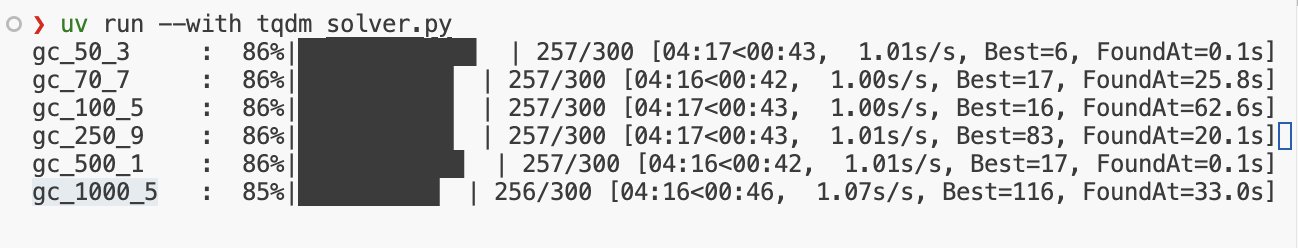